In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shreyaravi0/trade-csv/FINAL.csv
/kaggle/input/datasets/shreyaravi0/world-events/bq-results-20260429-074425-1777448717060.csv
/kaggle/input/datasets/shreyaravi0/clean-semiconductor-features/clean_semiconductor_features (1).csv


In [2]:
import torch, subprocess, sys

torch_ver = torch.__version__.split('+')[0]
cuda_tag  = ('cu' + torch.version.cuda.replace('.','')) if torch.cuda.is_available() else 'cpu'
wheel_url = f'https://data.pyg.org/whl/torch-{torch_ver}+{cuda_tag}.html'

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

pip('torch-scatter', '-f', wheel_url)
pip('torch-sparse',  '-f', wheel_url)
pip('torch-geometric')
pip('pycountry')

print(f'✅ PyTorch {torch.__version__} | device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 44.9 MB/s eta 0:00:00
✅ PyTorch 2.10.0+cpu | device: CPU


In [3]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, GraphSAGE
from torch_geometric.utils import to_networkx, add_self_loops

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

import networkx as nx
import pycountry

SEED   = 42
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)
print('✅ Ready | device:', device)

✅ Ready | device: cpu


In [4]:
df       = pd.read_csv('/kaggle/input/datasets/shreyaravi0/clean-semiconductor-features/clean_semiconductor_features (1).csv')
trade_df = pd.read_csv('/kaggle/input/datasets/shreyaravi0/trade-csv/FINAL.csv')

trade_df['trade_value'] = trade_df['fobvalue'].fillna(trade_df['cifvalue']).fillna(0)
trade_df = trade_df[['refYear','reporterDesc','partnerDesc','flowDesc','cmdCode','trade_value']]
trade_df.dropna(inplace=True)
trade_df['cmdCode'] = trade_df['cmdCode'].astype(str)
trade_df = trade_df[trade_df['cmdCode'].isin(['8486','8541','8542'])]
invalid  = ['World','Other Asia, nes','Areas, nes']
trade_df = trade_df[~trade_df['reporterDesc'].isin(invalid)]
trade_df = trade_df[~trade_df['partnerDesc'].isin(invalid)]
trade_df = trade_df[trade_df['trade_value'] > 0]

top_countries = (trade_df.groupby('reporterDesc')['trade_value']
                 .sum().sort_values(ascending=False).head(40).index)
trade_df = trade_df[trade_df['reporterDesc'].isin(top_countries)]
trade_df = trade_df[trade_df['partnerDesc'].isin(top_countries)]
df       = df[df['country'].isin(top_countries)]

print(f'Feature rows: {df.shape} | Trade rows: {trade_df.shape}')

Feature rows: (160, 17) | Trade rows: (27300, 6)


In [5]:
LABEL_FEATURES = [
    'volatility_score', 'dependency_score', 'disruption_index',
    'conflict_ratio', 'yoy_change', 'import_export_ratio',
]

X_label = StandardScaler().fit_transform(df[LABEL_FEATURES].values)
km      = KMeans(n_clusters=3, random_state=SEED, n_init=20)
raw_clusters = km.fit_predict(X_label)

# Map cluster IDs to risk level ordered by mean disruption_index
cluster_disruption = {c: df['disruption_index'].values[raw_clusters == c].mean() for c in range(3)}
rank               = sorted(cluster_disruption, key=cluster_disruption.get)
cluster_to_label   = {rank[0]: 0, rank[1]: 1, rank[2]: 2}
df['risk_label']   = pd.Series(raw_clusters).map(cluster_to_label).values

print('New risk label distribution:')
print(df['risk_label'].value_counts().sort_index())
print('\nMean disruption per label:')
print(df.groupby('risk_label')['disruption_index'].mean().round(4))

New risk label distribution:
risk_label
0    141
1     15
2      4
Name: count, dtype: int64

Mean disruption per label:
risk_label
0    0.1976
1    0.4187
2    0.4693
Name: disruption_index, dtype: float64


In [6]:
NODE_FEATURES = [
    'imports', 'exports', 'import_export_ratio', 'yoy_change',
    'volatility_score', 'dependency_score', 'disruption_index',
    'conflict_ratio', 'avg_tone', 'avg_goldstein',
]


def build_temporal_graph(df, trade_df, node_features, edge_pct_threshold=0.01):
    """
    Each node = (country, year). Two edge types:
      1. Trade edges   — real bilateral flows where share >= threshold
      2. Temporal edges — same country, consecutive years
    """
    df = df.sort_values(['country','refYear']).reset_index(drop=True)
    df['node_id'] = df['country'] + '_' + df['refYear'].astype(str)
    node_map = {nid: idx for idx, nid in enumerate(df['node_id'])}
    N        = len(node_map)

    scaler = StandardScaler()
    X      = scaler.fit_transform(df[node_features].fillna(0).values)

    # ── Trade edges ───────────────────────────────────────────────────────────
    bilateral = (trade_df
                 .groupby(['refYear','reporterDesc','partnerDesc'])['trade_value']
                 .sum().reset_index())
    rep_total = (bilateral.groupby(['refYear','reporterDesc'])['trade_value']
                 .sum().reset_index().rename(columns={'trade_value':'reporter_total'}))
    bilateral = bilateral.merge(rep_total, on=['refYear','reporterDesc'])
    bilateral['share'] = bilateral['trade_value'] / bilateral['reporter_total']
    bilateral = bilateral[bilateral['share'] >= edge_pct_threshold]

    edge_index, edge_weight = [], []
    for _, row in bilateral.iterrows():
        src_id = f"{row['reporterDesc']}_{int(row['refYear'])}"
        tgt_id = f"{row['partnerDesc']}_{int(row['refYear'])}"
        if src_id in node_map and tgt_id in node_map:
            s, t = node_map[src_id], node_map[tgt_id]
            edge_index  += [[s, t], [t, s]]
            edge_weight += [row['share'], row['share']]

    # ── Temporal edges ────────────────────────────────────────────────────────
    years = sorted(df['refYear'].unique())
    for country in df['country'].unique():
        for i in range(len(years) - 1):
            s_id = f"{country}_{years[i]}"
            t_id = f"{country}_{years[i+1]}"
            if s_id in node_map and t_id in node_map:
                s, t = node_map[s_id], node_map[t_id]
                edge_index  += [[s, t], [t, s]]
                edge_weight += [1.0, 1.0]

    ei = torch.tensor(edge_index,  dtype=torch.long).t().contiguous()
    ew = torch.tensor(edge_weight, dtype=torch.float)

    # Self-loops (Fix #3)
    ei, ew = add_self_loops(ei, ew, num_nodes=N, fill_value=1.0)

    data = Data(
        x          = torch.tensor(X, dtype=torch.float),
        edge_index = ei,
        edge_attr  = ew,
        y          = torch.tensor(df['risk_label'].values, dtype=torch.long)
    )
    data.node_map = node_map
    data.df       = df

    G       = to_networkx(data, to_undirected=True)
    degrees = [G.degree(i) for i in G.nodes()]
    print(f'Nodes: {N} | Edges: {data.num_edges} | Avg degree: {np.mean(degrees):.1f}')
    print(f'Isolated (degree<=1): {sum(1 for d in degrees if d<=1)}  (was 4 before fix)')
    return data


data = build_temporal_graph(df, trade_df, NODE_FEATURES)

Nodes: 160 | Edges: 4704 | Avg degree: 24.0
Isolated (degree<=1): 0  (was 4 before fix)


In [7]:
N       = data.num_nodes
indices = np.arange(N)
labels  = data.y.numpy()

train_idx, temp_idx = train_test_split(indices, test_size=0.40,
                                       random_state=SEED, stratify=labels)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50,
                                       random_state=SEED, stratify=labels[temp_idx])

for attr, idx in [('train_mask', train_idx), ('val_mask', val_idx), ('test_mask', test_idx)]:
    mask = torch.zeros(N, dtype=torch.bool)
    mask[idx] = True
    setattr(data, attr, mask)

print(f'Train: {data.train_mask.sum()} | Val: {data.val_mask.sum()} | Test: {data.test_mask.sum()}')
print('Test label distribution:', dict(zip(*np.unique(data.y[data.test_mask].numpy(), return_counts=True))))

Train: 96 | Val: 32 | Test: 32
Test label distribution: {np.int64(0): np.int64(28), np.int64(1): np.int64(3), np.int64(2): np.int64(1)}


In [8]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels // 2, out_channels)
        self.bn1   = nn.BatchNorm1d(hidden_channels)
        self.bn2   = nn.BatchNorm1d(hidden_channels // 2)
        self.drop  = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_weight)))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.conv3(x, edge_index, edge_weight)


class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels,
                             heads=1, concat=False, dropout=dropout)
        self.drop  = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.conv2(x, edge_index)


class SAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.net = GraphSAGE(in_channels, hidden_channels, num_layers=2,
                             out_channels=out_channels, dropout=dropout)

    def forward(self, x, edge_index, edge_weight=None):
        return self.net(x, edge_index)


def get_model(name, in_dim, num_classes):
    H = 64
    return {'GCN':  GCN(in_dim, H, num_classes),
            'GAT':  GAT(in_dim, H // 4, num_classes),
            'SAGE': SAGE(in_dim, H, num_classes)}[name]

print('✅ Models ready')

✅ Models ready


In [9]:
def train_model(model_name, data, epochs=300, lr=0.005, weight_decay=5e-4):
    data_d      = data.to(device)
    in_dim      = data_d.num_node_features
    num_classes = int(data_d.y.max().item()) + 1
    model       = get_model(model_name, in_dim, num_classes).to(device)

    cw = (1.0 / torch.bincount(data_d.y).float()).to(device)
    cw /= cw.sum()
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_acc, no_improve, best_state = 0, 0, None
    PATIENCE = 40
    ew = data_d.edge_attr if hasattr(data_d, 'edge_attr') else None

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out  = model(data_d.x, data_d.edge_index, ew)
        loss = criterion(out[data_d.train_mask], data_d.y[data_d.train_mask])
        loss.backward(); optimizer.step(); scheduler.step()
        tr_acc = (out[data_d.train_mask].argmax(1) == data_d.y[data_d.train_mask]).float().mean().item()

        model.eval()
        with torch.no_grad():
            out_v    = model(data_d.x, data_d.edge_index, ew)
            val_loss = criterion(out_v[data_d.val_mask], data_d.y[data_d.val_mask]).item()
            val_acc  = (out_v[data_d.val_mask].argmax(1) == data_d.y[data_d.val_mask]).float().mean().item()

        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  ⏹ Early stop @ epoch {epoch}')
                break

        if epoch % 50 == 0 or epoch == 1:
            print(f'  [{model_name}] ep {epoch:>3} | '
                  f'loss {loss.item():.4f} | train {tr_acc:.3f} | val {val_acc:.3f}')

    model.load_state_dict(best_state)
    print(f'  ✅ {model_name} best val acc: {best_val_acc:.4f}\n')
    return model, history


print('=== GCN ===');  gcn_model,  gcn_history  = train_model('GCN',  data)
print('=== GAT ===');  gat_model,  gat_history  = train_model('GAT',  data)
print('=== SAGE ==='); sage_model, sage_history = train_model('SAGE', data)

=== GCN ===
  [GCN] ep   1 | loss 1.4713 | train 0.125 | val 0.125
  [GCN] ep  50 | loss 0.2393 | train 0.896 | val 0.875
  [GCN] ep 100 | loss 0.1309 | train 0.948 | val 0.906
  ⏹ Early stop @ epoch 131
  ✅ GCN best val acc: 0.9375

=== GAT ===
  [GAT] ep   1 | loss 1.2178 | train 0.646 | val 0.562
  ⏹ Early stop @ epoch 41
  ✅ GAT best val acc: 0.5625

=== SAGE ===
  [SAGE] ep   1 | loss 1.2312 | train 0.083 | val 0.156
  [SAGE] ep  50 | loss 0.0237 | train 1.000 | val 0.969
  ⏹ Early stop @ epoch 57
  ✅ SAGE best val acc: 1.0000



In [10]:
@torch.no_grad()
def evaluate(model, data, mask, model_name='Model'):
    data_d = data.to(device)
    model.eval()
    ew    = data_d.edge_attr if hasattr(data_d, 'edge_attr') else None
    out   = model(data_d.x, data_d.edge_index, ew)
    preds = out[mask].argmax(dim=1).cpu().numpy()
    trues = data_d.y[mask].cpu().numpy()
    probs = F.softmax(out[mask], dim=1).cpu().numpy()
    print(f'\n── {model_name} ──')
    print(classification_report(trues, preds,
          target_names=['Low Risk', 'Medium Risk', 'High Risk']))
    try:
        print(f'ROC-AUC (OvR): {roc_auc_score(trues, probs, multi_class="ovr"):.4f}')
    except Exception as e:
        print(f'ROC-AUC: {e}')
    return preds, trues


test_mask_d = data.test_mask.to(device)
preds_gcn,  trues = evaluate(gcn_model,  data, test_mask_d, 'GCN')
preds_gat,  _     = evaluate(gat_model,  data, test_mask_d, 'GAT')
preds_sage, _     = evaluate(sage_model, data, test_mask_d, 'GraphSAGE')


── GCN ──
              precision    recall  f1-score   support

    Low Risk       1.00      0.89      0.94        28
 Medium Risk       0.75      1.00      0.86         3
   High Risk       0.00      0.00      0.00         1

    accuracy                           0.88        32
   macro avg       0.58      0.63      0.60        32
weighted avg       0.95      0.88      0.91        32

ROC-AUC (OvR): 0.6774

── GAT ──
              precision    recall  f1-score   support

    Low Risk       0.89      0.57      0.70        28
 Medium Risk       0.07      0.33      0.12         3
   High Risk       0.00      0.00      0.00         1

    accuracy                           0.53        32
   macro avg       0.32      0.30      0.27        32
weighted avg       0.78      0.53      0.62        32

ROC-AUC (OvR): 0.4492

── GraphSAGE ──
              precision    recall  f1-score   support

    Low Risk       1.00      0.96      0.98        28
 Medium Risk       0.60      1.00      0.75   

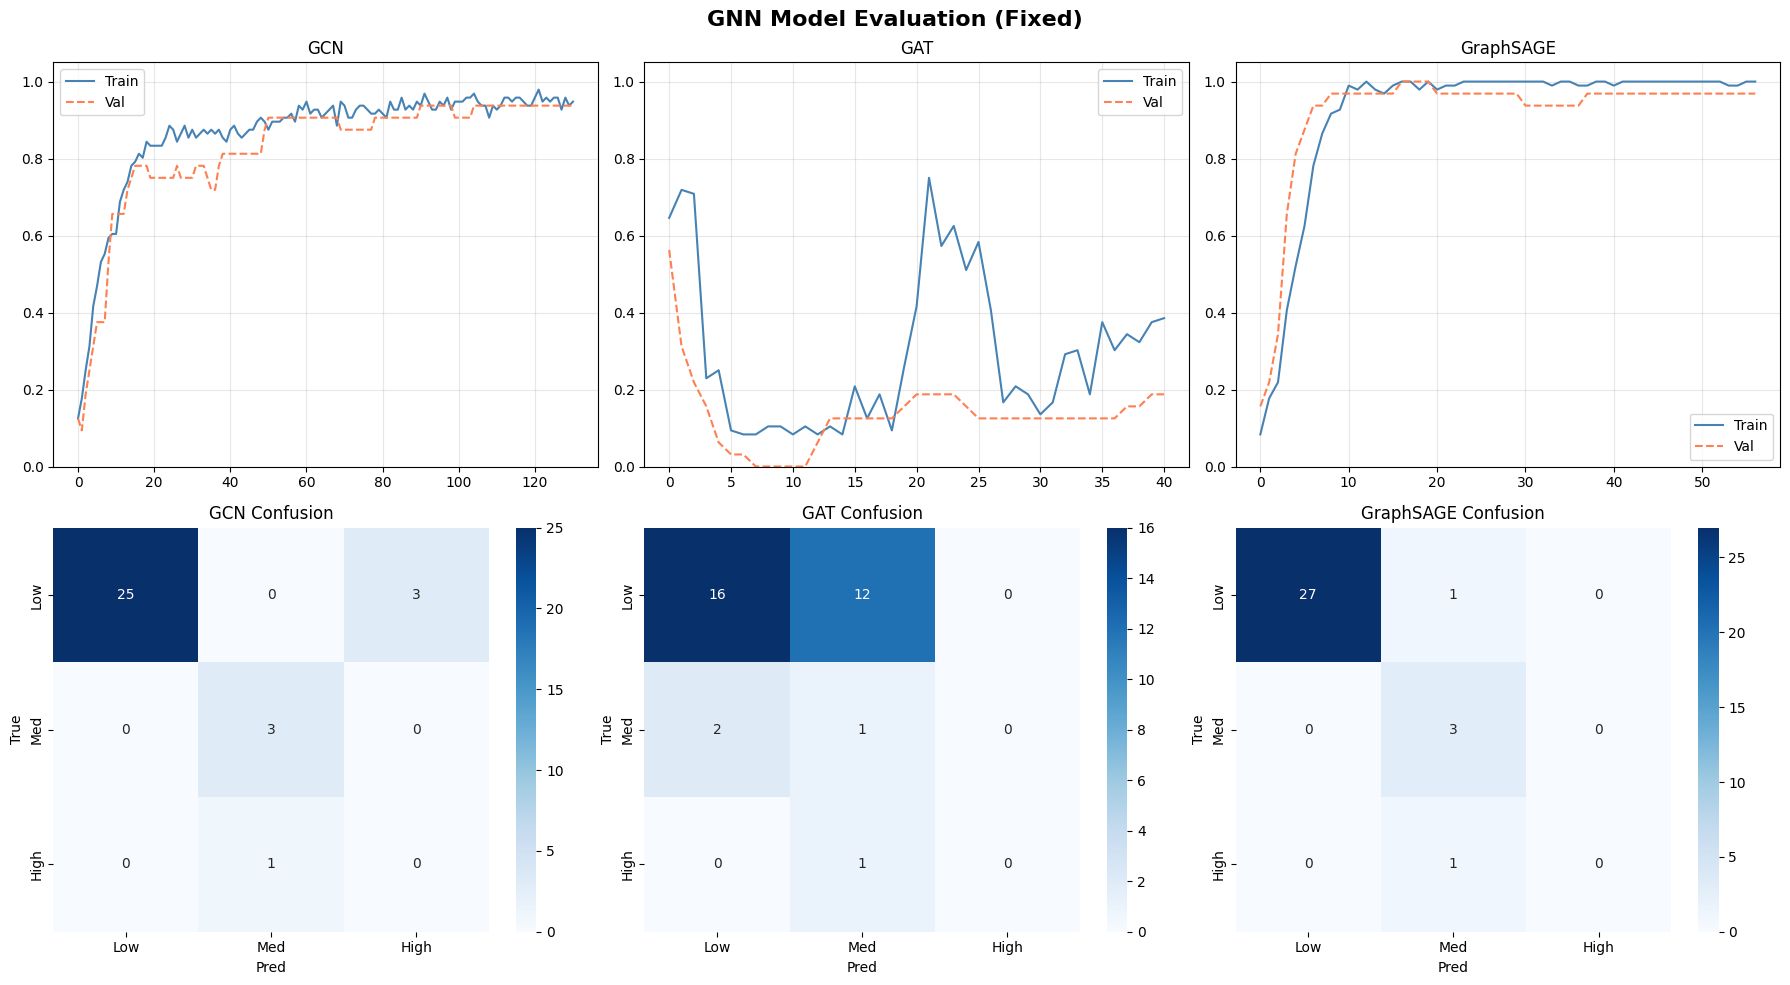

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('GNN Model Evaluation (Fixed)', fontsize=16, fontweight='bold')

runs = [('GCN', gcn_history, preds_gcn),
        ('GAT', gat_history, preds_gat),
        ('GraphSAGE', sage_history, preds_sage)]

for col, (name, hist, preds) in enumerate(runs):
    ax = axes[0, col]
    ax.plot(hist['train_acc'], label='Train', color='steelblue')
    ax.plot(hist['val_acc'],   label='Val',   color='coral', linestyle='--')
    ax.set_title(name); ax.legend(); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

    ax2 = axes[1, col]
    cm = confusion_matrix(trues, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax2, cmap='Blues',
                xticklabels=['Low','Med','High'], yticklabels=['Low','Med','High'])
    ax2.set_title(f'{name} Confusion'); ax2.set_ylabel('True'); ax2.set_xlabel('Pred')

plt.tight_layout()
plt.savefig('model_evaluation_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
@torch.no_grad()
def predict_all(model, data):
    data_d = data.to(device)
    model.eval()
    ew    = data_d.edge_attr if hasattr(data_d, 'edge_attr') else None
    out   = model(data_d.x, data_d.edge_index, ew)
    probs = F.softmax(out, dim=1).cpu().numpy()
    return out.argmax(dim=1).cpu().numpy(), probs

all_preds, all_probs = predict_all(gcn_model, data)

node_df = data.df.reset_index(drop=True).copy()
node_df['predicted_risk'] = all_preds
node_df['prob_low']       = all_probs[:, 0]
node_df['prob_medium']    = all_probs[:, 1]
node_df['prob_high']      = all_probs[:, 2]
node_df['confidence']     = all_probs.max(axis=1)
node_df['risk_category']  = node_df['predicted_risk'].map({0:'Low',1:'Medium',2:'High'})

results_2022 = node_df[node_df['refYear'] == 2022].copy()
print(results_2022[['country','risk_category','confidence','disruption_index']]
      .sort_values('confidence', ascending=False).to_string(index=False))

# Export
node_df.to_csv('gnn_predictions_all_years.csv', index=False)
results_2022.to_csv('gnn_risk_predictions_2022.csv', index=False)
print('\n✅ Exported: gnn_predictions_all_years.csv + gnn_risk_predictions_2022.csv')

# Model comparison
print('\n── Model Comparison ──')
for name, hist in [('GCN', gcn_history),('GAT', gat_history),('GraphSAGE', sage_history)]:
    print(f'  {name:12s} best val acc: {max(hist["val_acc"]):.4f}')

             country risk_category  confidence  disruption_index
           Australia        Medium    0.999896          0.381781
              Brazil        Medium    0.999549          0.327501
China, Hong Kong SAR        Medium    0.989725          0.573254
           Indonesia           Low    0.979431          0.176021
              Canada           Low    0.978997          0.217508
              France           Low    0.977071          0.169771
                 USA           Low    0.976843          0.197905
         Switzerland           Low    0.976288          0.157513
            Malaysia           Low    0.974855          0.222248
             Belgium           Low    0.973306          0.194848
             Finland           Low    0.973262          0.166202
             Austria           Low    0.972910          0.173347
               Malta           Low    0.971996          0.203195
           Singapore           Low    0.969792          0.237266
              Mexico     